# Irrigação inteligente de uma horta comunitária

**Trabalho de Aprendizado por Reforço — notebook e relatório**

Integrantes: Nicolas Cussioli Raimundo, Marcelo Fontana. Professor: Gabriel de Oliveira Ramos.

**Apresentação no YouTube:** [incluir link após gravação com a fala de todos os integrantes]. Divulgação em rede social: [opcional].

Este relatório contém código executável e dados reais. O treinamento é executado pelo módulo de experimentos, com comando explícito, e as células seguintes carregam seus registros sem repetir os treinamentos.

## 1. Introdução

Uma horta comunitária precisa distribuir água entre canteiros com necessidades diferentes. Irrigar cedo pode desperdiçar água caso chova; esperar demais pode comprometer a saúde das plantas. Reabastecer ocupa um turno e também permite que o solo continue secando. Esse cenário constitui um problema de decisão sequencial com consequências futuras e incerteza.

Construímos um simulador didático próprio no Gymnasium e comparamos DQN, PPO e A2C, da Stable-Baselines3. O ambiente combina quatro canteiros, reservatório limitado, saúde persistente, falta e excesso de água e clima probabilístico. A comparação utiliza uma busca controlada de hiperparâmetros, várias sementes de treinamento e episódios separados de validação e teste.

O cenário foi elaborado para o trabalho. Não afirmamos ineditismo na literatura nem fidelidade agronômica: todos os coeficientes e unidades são sintéticos.

Nas condições avaliadas, PPO obteve o maior retorno médio entre os métodos de RL: **55.90 ± 0.26**, com sucesso em **94.2%** dos episódios, em média entre treinamentos. A heurística apresentou retorno **55.04**. Esses resultados se referem a este simulador e protocolo; não demonstram superioridade geral de um algoritmo.

## 2. Modelagem do problema

### 2.1 Estados, ações e horizonte

O MDP é $M=(S,A,P,R,H)$, com horizonte $H=60$. O estado contém quatro umidades $u_i$, quatro saúdes $h_i$, água $w$, regime climático $c$ e tempo restante $\tau$. Umidade e saúde pertencem a $[0,1]$, e $w\in[0,8]$. As ações são: irrigar canteiro 1, 2, 3 ou 4; reabastecer; esperar.

A observação é um vetor `Box(0,1,(13,))`: quatro umidades, quatro saúdes, água dividida por oito, três indicadores one-hot do clima e tempo restante dividido por 60. As ações usam `Discrete(6)`. A saúde registra os efeitos de estresse anteriores; o tempo restante permite representar o horizonte finito. Ambos são necessários para o estado conter as informações que influenciam as próximas transições e recompensas.

As condições iniciais são $u_i\sim U(0{,}4;0{,}7)$, $h_i=1$, $w\sim U(4;8)$ e clima seco/ameno/chuvoso com probabilidades $(0{,}50;0{,}35;0{,}15)$. O episódio termina ao completar 60 turnos ou morrerem todas as plantas. Como o horizonte pertence ao MDP e aparece no estado, seu fim gera `terminated=True`, e não `truncated=True`.

### 2.2 Clima e transições

A matriz abaixo usa a ordem seco, ameno, chuvoso tanto nas linhas como nas colunas:

$$P(c_{t+1}\mid c_t)=\begin{bmatrix}0{,}80&0{,}18&0{,}02\\0{,}25&0{,}55&0{,}20\\0{,}10&0{,}30&0{,}60\end{bmatrix}.$$

| Parâmetro | Seco | Ameno | Chuvoso |
|---|---:|---:|---:|
| Evaporação base | 0,018 | 0,012 | 0,006 |
| Probabilidade de chuva | 0,05 | 0,15 | 0,65 |
| Quantidade quando chove | 0,02 | 0,04 | 0,08 |

| Canteiro | Umidade mínima ideal | Máxima ideal | Multiplicador de evaporação | Drenagem por turno |
|---|---:|---:|---:|---:|
| 1 | 0,30 | 0,70 | 0,8 | 0,010 |
| 2 | 0,38 | 0,75 | 1,0 | 0,012 |
| 3 | 0,34 | 0,68 | 1,2 | 0,016 |
| 4 | 0,42 | 0,80 | 1,1 | 0,009 |

Uma irrigação usa $q=\min(1,w)$ unidades e acrescenta $0{,}20q$ à umidade do canteiro vivo selecionado. Sem água ou com uma planta morta, a irrigação não tem efeito e recebe penalidade. Reabastecer coloca oito unidades no reservatório e consome o turno; a fonte externa de reposição é ilimitada, mas requer essa ação. Água em excesso no solo é perdida pelo recorte em umidade máxima um, continuando a contar como consumida.

Para cada canteiro, a evaporação é a base climática multiplicada pela demanda e por um fator independente $U(0{,}9;1{,}1)$. A nova umidade é a anterior mais irrigação e chuva menos evaporação e drenagem, limitada a $[0,1]$. Primeiro ocorrem ação e efeitos do clima atual; em seguida são atualizadas as saúdes, sorteado o clima seguinte e decrementado o tempo restante.

### 2.3 Saúde e recompensa

Sejam $d_i^- = \max(L_i-u_i',0)$ e $d_i^+ = \max(u_i'-U_i,0)$. Uma planta viva ganha 0,015 de saúde quando a umidade está na faixa ideal, perde $0{,}04+0{,}30d_i^-$ quando seca e perde $0{,}02+0{,}15d_i^+$ quando encharcada. A saúde é limitada a $[0,1]$; chegar a zero é irreversível.

$$r_t=\overline{h}_{t+1}-0{,}10q_t-2d_t-0{,}05\mathbb{1}[a_t=\text{reabastecer}]-0{,}10\mathbb{1}[\text{irrigação inválida}],$$

em que $d_t$ conta apenas as plantas que morreram nesse turno. O termo de saúde incentiva manter todos os canteiros vivos; os custos de água e reabastecimento evitam irrigar indiscriminadamente. A saúde média inclui plantas mortas. Esses pesos foram fixados antes da busca de hiperparâmetros e não ajustados usando os resultados de teste.

O gerador `self.np_random` controla a aleatoriedade. A quantidade e a ordem dos sorteios do clima não dependem da ação, permitindo comparar políticas sob os mesmos eventos externos quando usam a mesma semente. As regras do simulador e o regime atual são suficientes para caracterizar a distribuição do próximo estado; o histórico não acrescenta informação necessária.

### 2.4 Implementação

A célula seguinte contém o código real de `horta/env.py`, incluído automaticamente para manter texto e implementação juntos. A renderização oferece modos `rgb_array`, `human` e `ansi`; a imagem é usada para compreensão e apresentação, enquanto a política recebe o vetor numérico. A imagem abaixo exemplifica a heurística na semente 1000, turno 12, e não um resultado de treinamento.

In [1]:
"""MDP sintético de irrigação. Todas as unidades são adimensionais."""
from __future__ import annotations

import gymnasium as gym
import numpy as np
from gymnasium import spaces


class HortaEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array", "human", "ansi"], "render_fps": 4}
    VERSION = "1.0.0"
    HORIZON = 60
    CAPACITY = 8.0
    IRRIGATION = 0.20
    LOW = np.array([0.30, 0.38, 0.34, 0.42])
    HIGH = np.array([0.70, 0.75, 0.68, 0.80])
    DEMAND = np.array([0.8, 1.0, 1.2, 1.1])
    DRAINAGE = np.array([0.010, 0.012, 0.016, 0.009])
    WEATHER = ("Seco", "Ameno", "Chuvoso")
    TRANSITION = np.array([[0.80, 0.18, 0.02], [0.25, 0.55, 0.20], [0.10, 0.30, 0.60]])
    EVAPORATION = np.array([0.018, 0.012, 0.006])
    RAIN_PROBABILITY = np.array([0.05, 0.15, 0.65])
    RAIN_AMOUNT = np.array([0.02, 0.04, 0.08])
    ACTIONS = ("Irrigar 1", "Irrigar 2", "Irrigar 3", "Irrigar 4", "Reabastecer", "Esperar")

    def __init__(self, render_mode=None):
        if render_mode is not None and render_mode not in self.metadata["render_modes"]:
            raise ValueError(f"render_mode inválido: {render_mode}")
        self.render_mode = render_mode
        self.action_space = spaces.Discrete(6)
        self.observation_space = spaces.Box(0.0, 1.0, shape=(13,), dtype=np.float32)
        self._window = None
        self._clock = None
        self._done = True

    def _obs(self):
        return np.concatenate((self.moisture, self.health, [self.water / self.CAPACITY],
                               np.eye(3)[self.weather], [(self.HORIZON - self.turn) / self.HORIZON])).astype(np.float32)

    def _info(self):
        return {"water_used": float(self.water_used), "survival_fraction": float(np.mean(self.health > 0)),
                "final_mean_health": float(self.health.mean()), "weather": int(self.weather),
                "turn": int(self.turn), "is_success": bool(self.turn == self.HORIZON and
                       np.all(self.health > 0) and self.health.mean() >= 0.5)}

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.moisture = self.np_random.uniform(0.40, 0.70, size=4)
        self.health = np.ones(4, dtype=np.float64)
        self.water = float(self.np_random.uniform(4, self.CAPACITY))
        self.weather = int(self.np_random.choice(3, p=[0.50, 0.35, 0.15]))
        self.turn = 0
        self.water_used = 0.0
        self.last_action = "Início"
        self._done = False
        if self.render_mode == "human":
            self.render()
        return self._obs(), self._info()

    def step(self, action):
        if self._done:
            raise RuntimeError("Execute reset antes de iniciar ou continuar um episódio encerrado.")
        if not self.action_space.contains(action):
            raise ValueError(f"Ação inválida: {action}")
        action = int(action)
        alive = self.health > 0
        used, refill, invalid = 0.0, 0, 0
        if action < 4:
            if alive[action] and self.water > 0:
                used = min(1.0, self.water)
                self.moisture[action] += self.IRRIGATION * used
                self.water -= used
            else:
                invalid = 1
        elif action == 4:
            self.water = self.CAPACITY
            refill = 1

        # Número/ordem de sorteios são independentes da ação: clima pareado por semente.
        rain = self.RAIN_AMOUNT[self.weather] if self.np_random.random() < self.RAIN_PROBABILITY[self.weather] else 0.0
        evaporation = self.EVAPORATION[self.weather] * self.DEMAND * self.np_random.uniform(0.9, 1.1, 4)
        self.moisture = np.clip(self.moisture + rain - evaporation - self.DRAINAGE, 0, 1)
        dry = np.maximum(self.LOW - self.moisture, 0)
        wet = np.maximum(self.moisture - self.HIGH, 0)
        in_band = (dry == 0) & (wet == 0)
        delta = np.where(in_band, 0.015, np.where(dry > 0, -0.04 - 0.30 * dry, -0.02 - 0.15 * wet))
        self.health = np.where(alive, np.clip(self.health + delta, 0, 1), 0)
        deaths = int(np.sum(alive & (self.health == 0)))
        reward = float(self.health.mean() - 0.10 * used - 2.0 * deaths - 0.05 * refill - 0.10 * invalid)
        self.water_used += used
        self.weather = int(self.np_random.choice(3, p=self.TRANSITION[self.weather]))
        self.turn += 1
        self.last_action = self.ACTIONS[action]
        self._done = self.turn >= self.HORIZON or not np.any(self.health > 0)
        info = self._info()
        info.update({"rain": float(rain), "water_step": used, "new_deaths": deaths, "invalid_action": invalid})
        if self.render_mode == "human":
            self.render()
        return self._obs(), reward, bool(self._done), False, info

    def render(self):
        if self.render_mode == "ansi":
            return (f"Turno {self.turn}/{self.HORIZON} | {self.WEATHER[self.weather]} | água {self.water:.1f}/8\n"
                    f"Umidade {np.round(self.moisture, 2)} | Saúde {np.round(self.health, 2)} | {self.last_action}")
        if self.render_mode is None:
            return None
        from PIL import Image, ImageDraw, ImageFont
        canvas = Image.new("RGB", (960, 600), "#f5f3e9")
        draw = ImageDraw.Draw(canvas)
        from matplotlib.font_manager import findfont
        font_path = findfont("DejaVu Sans")
        title = ImageFont.truetype(font_path, 26)
        font = ImageFont.truetype(font_path, 18)
        draw.text((30, 20), "Horta comunitária", font=title, fill="#243a32")
        draw.text((30, 60), f"Turno {self.turn}/60   |   Clima: {self.WEATHER[self.weather]}   |   {self.last_action}", font=font, fill="#243a32")
        for i in range(4):
            x, y = 30 + (i % 2) * 330, 120 + (i // 2) * 220
            draw.rounded_rectangle((x, y, x + 300, y + 195), radius=12, fill="#ffffff", outline="#a8b5a1", width=2)
            draw.text((x + 15, y + 12), f"Canteiro {i + 1}", font=font, fill="#243a32")
            leaf = "#3d8c55" if self.health[i] > 0 else "#827569"
            draw.line((x + 270, y + 75, x + 270, y + 150), fill=leaf, width=5)
            draw.ellipse((x + 240, y + 72, x + 270, y + 105), fill=leaf)
            draw.ellipse((x + 270, y + 93, x + 295, y + 126), fill=leaf)
            for j, (label, value, color) in enumerate((("Umidade", self.moisture[i], "#468dcc"), ("Saúde", self.health[i], leaf))):
                by = y + 60 + 60 * j
                draw.text((x + 15, by - 5), f"{label}: {value:.0%}", font=font, fill="#243a32")
                draw.rectangle((x + 15, by + 25, x + 225, by + 41), fill="#e4e8e2")
                draw.rectangle((x + 15, by + 25, x + 15 + int(210 * value), by + 41), fill=color)
                if j == 0:
                    for boundary in (self.LOW[i], self.HIGH[i]):
                        bx = x + 15 + int(210 * boundary)
                        draw.line((bx, by + 21, bx, by + 45), fill="#334333", width=2)
        draw.text((730, 120), "Reservatório", font=font, fill="#243a32")
        draw.rectangle((765, 170, 885, 430), fill="#d9e4eb", outline="#46677d", width=3)
        draw.rectangle((768, 427 - int(254 * self.water / 8), 882, 427), fill="#468dcc")
        draw.text((740, 450), f"{self.water:.1f}/8 unidades", font=font, fill="#243a32")
        draw.text((30, 565), f"Água usada: {self.water_used:.1f}   |   Simulação didática; unidades sintéticas", font=font, fill="#243a32")
        frame = np.asarray(canvas).copy()
        if self.render_mode == "rgb_array":
            return frame
        import pygame
        if self._window is None:
            pygame.init()
            self._window = pygame.display.set_mode((960, 600))
            self._clock = pygame.time.Clock()
        pygame.event.pump()
        self._window.blit(pygame.surfarray.make_surface(frame.transpose(1, 0, 2)), (0, 0))
        pygame.display.flip()
        self._clock.tick(self.metadata["render_fps"])

    def close(self):
        if self._window is not None:
            import pygame
            pygame.display.quit()
            pygame.quit()
            self._window = None


def heuristic_action(env: HortaEnv):
    """Irriga o maior déficit; reabastece se houver necessidade sem água."""
    deficit = np.where(env.health > 0, env.LOW + 0.07 - env.moisture, -np.inf)
    if np.max(deficit) <= 0:
        return 5
    if env.water < 1:
        return 4
    return int(np.argmax(deficit))


API do Gymnasium e compatibilidade com SB3 verificadas.


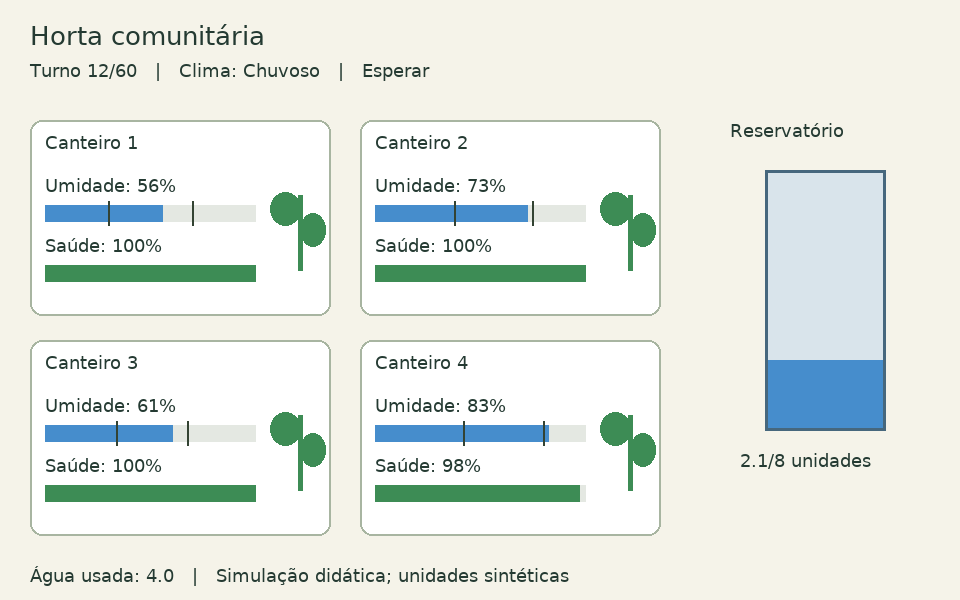

In [2]:
from IPython.display import display, Image, Code
from gymnasium.utils.env_checker import check_env as gym_check
from stable_baselines3.common.env_checker import check_env as sb3_check

gym_check(HortaEnv(), skip_render_check=True)
sb3_check(HortaEnv(), warn=True)
print('API do Gymnasium e compatibilidade com SB3 verificadas.')
display(Image(filename='reports/figures/ambiente.png'))

Além da API, seis testes verificam conservação de água, reabastecimento, morte irreversível, encerramento no horizonte, limites das observações, formato da imagem e reprodução do clima por semente independentemente das ações. Executar `python -m unittest discover -s tests -v` para reproduzi-los.

## 3. Metodologia de experimentos

### 3.1 Algoritmos

| Método | Princípio | Justificativa |
|---|---|---|
| DQN | Rede para valores de ação, replay buffer e rede alvo; off-policy | Amplia o Q-learning tabular trabalhado nas aulas |
| PPO | Ator e crítico com objetivo de política sujeito a clipping; on-policy | Método usado no módulo 3; referência para aprendizagem de política |
| A2C | Ator e crítico com atualizações por vantagem; on-policy | Compara outro método de política e estimação de valor |

Os três suportam ações discretas e usam `MlpPolicy`. O DQN usa camadas ocultas `[64,64]`; PPO e A2C usam `[64,64]` no ator e no crítico. Não se trata de uma igualdade de número de parâmetros: as famílias têm estruturas distintas. Todos usam CPU, um ambiente por treino e uma thread de PyTorch por processo. O tempo de treino é reportado, mas a execução simultânea pode introduzir variação por disputa dos recursos do computador.

### 3.2 Busca de hiperparâmetros

Propusemos uma base e três variações por algoritmo; cada variação altera um parâmetro em relação à base. A busca não é exaustiva nem um fatorial completo. Os parâmetros de interesse são a taxa de aprendizado, o desconto e um parâmetro específico: duração da exploração no DQN, clipping no PPO e entropia no A2C.

| Algoritmo | Base | Variação 1 | Variação 2 | Variação 3 |
|---|---|---|---|---|
| DQN | lr=0,0001; gamma=0,99; exploração=0,30 | lr=0,0003 | gamma=0,95 | exploração=0,50 |
| PPO | lr=0,0003; gamma=0,99; clip=0,20 | lr=0,0001 | gamma=0,95 | clip=0,10 |
| A2C | lr=0,0007; gamma=0,99; entropia=0,01 | lr=0,0003 | gamma=0,95 | entropia=0,05 |

`learning_rate` controla o tamanho das atualizações; `gamma`, o peso de retornos futuros. No DQN, os parâmetros de buffer e de exploração regulam armazenamento, reutilização e ações aleatórias. No PPO, `n_steps`, `batch_size` e `n_epochs` regulam coleta e otimização; `gae_lambda` controla a estimativa de vantagem. Em PPO/A2C, `ent_coef` estimula diversidade da política. No A2C, `vf_coef` pesa a perda do crítico e `use_rms_prop` seleciona o otimizador. A célula seguinte mostra todas as configurações propostas; os arquivos `run.json` registram parâmetros efetivos e versões utilizadas.

In [3]:
from pathlib import Path
import json, inspect
import pandas as pd
from horta.experiments import candidates, configuration, collect_runs, evaluate, run_trial

config = configuration()
rows = [{'algorithm': a, 'config_id': c, **p} for (a,c), p in candidates(config).items()]
display(pd.DataFrame(rows)[['algorithm','config_id','learning_rate','gamma']])
for algorithm, specification in config['algorithms'].items():
    print(algorithm, '— demais parâmetros da base:')
    print(json.dumps(specification['base'], indent=2))
print('Sementes:', json.dumps(config['seeds']))
print('Orçamentos:', config['budgets'])
print('Versões:', json.loads(next(Path('results/pilot').glob('*/run.json')).read_text(encoding='utf-8'))['dependencies'])

,algorithm,config_id,learning_rate,gamma
0,DQN,base,0.0001,0.99
1,DQN,lr_3e-4,0.0003,0.99
2,DQN,gamma_095,0.0001,0.95
3,DQN,exploracao_050,0.0001,0.99
4,PPO,base,0.0003,0.99
5,PPO,lr_1e-4,0.0001,0.99
6,PPO,gamma_095,0.0003,0.95
7,PPO,clip_010,0.0003,0.99
8,A2C,base,0.0007,0.99
9,A2C,lr_3e-4,0.0003,0.99


DQN — demais parâmetros da base:
{
  "learning_rate": 0.0001,
  "gamma": 0.99,
  "buffer_size": 50000,
  "learning_starts": 5000,
  "batch_size": 64,
  "train_freq": 4,
  "gradient_steps": 1,
  "target_update_interval": 1000,
  "exploration_fraction": 0.3,
  "exploration_final_eps": 0.05,
  "policy_kwargs": {
    "net_arch": [
      64,
      64
    ]
  }
}
PPO — demais parâmetros da base:
{
  "learning_rate": 0.0003,
  "gamma": 0.99,
  "n_steps": 1024,
  "batch_size": 64,
  "n_epochs": 10,
  "gae_lambda": 0.95,
  "clip_range": 0.2,
  "ent_coef": 0.01,
  "policy_kwargs": {
    "net_arch": {
      "pi": [
        64,
        64
      ],
      "vf": [
        64,
        64
      ]
    }
  }
}
A2C — demais parâmetros da base:
{
  "learning_rate": 0.0007,
  "gamma": 0.99,
  "n_steps": 32,
  "gae_lambda": 1,
  "ent_coef": 0.01,
  "vf_coef": 0.5,
  "max_grad_norm": 0.5,
  "use_rms_prop": true,
  "policy_kwargs": {
    "net_arch": {
      "pi": [
        64,
        64
      ],
      "vf": [

### 3.3 Protocolo, métricas e seleção

1. Piloto: configuração base de cada algoritmo, semente 7 e 20.480 interações. Serve para verificar o pipeline e medir custo; não decide a configuração vencedora. O orçamento originalmente proposto foi mantido.
2. Busca: 12 configurações × 3 sementes de treino (11, 22, 33), com 102.400 interações por execução. Avaliar o modelo do fim do orçamento em 30 episódios de validação (sementes 1000 a 1029).
3. Seleção por algoritmo: maior média dos retornos de validação, primeiro calculada por semente de treinamento e depois entre as três sementes. Em empate numérico, usar menor consumo médio de água. Não escolher o melhor checkpoint intermediário.
4. Final: treinar do zero a configuração selecionada de cada algoritmo com sementes 101 a 105 e 307.200 interações. Cada modelo é avaliado em 100 episódios de teste (sementes 2000 a 2099), com `deterministic=True`, sem aprendizado.
5. Referências: política aleatória, com gerador de ações separado do clima; e regra que irriga o maior déficit relativo ao limiar mínimo mais 0,07, reabastece quando necessário e espera quando nenhum canteiro precisa de água. Avaliar no mesmo teste.

O orçamento total do protocolo é 8.355.840 interações de treino, em 54 execuções, fora o diagnóstico inicial descartado. Os valores são múltiplos dos rollouts usados no PPO/A2C. Os registros permitem conferir passos efetivamente realizados. As sementes de validação não são usadas para medir o desempenho final; as sementes de teste não são usadas para escolher hiperparâmetros.

| Métrica | Definição |
|---|---|
| Retorno episódico | Soma não descontada das recompensas; métrica principal |
| Sobrevivência final | Fração de canteiros com saúde maior que zero |
| Saúde final média | Média da saúde dos quatro canteiros no fim |
| Água usada | Soma da água efetivamente aplicada; unidades sintéticas |
| Sucesso | Chegar ao turno 60 com todos vivos e saúde média ≥ 0,5 |
| Custo | Tempo e interações reais do treino |

O resultado de cada modelo é a média dos seus 100 episódios. O relatório apresenta a média e o desvio padrão amostral entre as cinco sementes de treinamento. Episódios de um único modelo não são tratados como treinamentos independentes. As referências fixas não possuem desvio entre treinamentos; uma ausência de barra para elas não indica ausência de incerteza entre cenários.

### 3.4 Código de treinamento e avaliação

O módulo executa cada tentativa com ambiente separado, salva o modelo localmente e os resultados por episódio em CSV, e registra falhas. A retomada recusa alterações de código/protocolo para não misturar dados incompatíveis. A célula abaixo mostra o código usado. A execução dos experimentos é opt-in: abrir o notebook para revisar o relatório não reinicia horas de treinamento.

In [4]:
display(Code(inspect.getsource(evaluate), language='python'))
display(Code(inspect.getsource(run_trial), language='python'))

def evaluate(model, seeds, *, baseline=None):
    env = HortaEnv()
    rows = []
    for seed in seeds:
        obs, _ = env.reset(seed=int(seed))
        action_rng = np.random.default_rng(int(seed) + 100000)
        total = 0.0
        done = False
        while not done:
            if baseline == "random":
                action = int(action_rng.integers(6))
            elif baseline == "heuristic":
                action = heuristic_action(env)
            else:
                action, _ = model.predict(obs, deterministic=True)
                action = int(action.item())
            obs, reward, terminated, truncated, info = env.step(action)
            total += reward
            done = terminated or truncated
        rows.append({"evaluation_seed": int(seed), "episode_return": total, "episode_length": env.turn,
                     "survival_fraction": info["survival_fraction"], "final_mean_health": info["final_mean_health"],
                     "water_used": info["water_used"], "success": int(info["is_success"])})
    env.close()
    return rows

def run_trial(stage, algo, config_id, seed, params, config):
    trial_id = f"{algo}__{config_id}__{seed}"
    path = ROOT / "results" / stage / trial_id
    path.mkdir(parents=True, exist_ok=True)
    source_hash = hashlib.sha256((ROOT / "horta/env.py").read_bytes()).hexdigest()
    signature = hashlib.sha256(json.dumps({"params": params, "budget": config["budgets"][stage],
        "env": source_hash, "versions": versions(), "eval_seeds": config["seeds"]["test" if stage == "final" else "validation"]}, sort_keys=True).encode()).hexdigest()
    meta_path = path / "run.json"
    if meta_path.exists():
        old = json.loads(meta_path.read_text(encoding="utf-8"))
        if old.get("signature") != signature:
            raise RuntimeError(f"Protocolo mudou para {trial_id}; use outra pasta/versão para preservar tentativas.")
        if old.get("status") == "completed":
            print(f"Já concluído: {stage}/{trial_id}", flush=True)
            return old
        archive = path / "retries" / f"attempt_{len(list((path / 'retries').glob('attempt_*'))) + 1}"
        archive.mkdir(parents=True, exist_ok=True)
        for artifact in path.iterdir():
            if artifact.is_file() and artifact.suffix != ".tmp":
                shutil.copy2(artifact, archive / artifact.name)
    meta = {"stage": stage, "algorithm": algo, "config_id": config_id, "training_seed": seed,
            "status": "running", "parameters_requested": params, "signature": signature,
            "environment_version": HortaEnv.VERSION, "environment_sha256": source_hash,
            "dependencies": versions(), "hardware": {"platform": platform.platform(), "processor": platform.processor(),
                 "device": "cpu", "torch_threads": torch.get_num_threads()},
            "requested_steps": config["budgets"][stage]}
    atomic_json(meta_path, meta)
    model_dir = ROOT / "models" / stage
    model_dir.mkdir(parents=True, exist_ok=True)
    env = Monitor(HortaEnv(), filename=str(path / "monitor.csv"))
    start = time.perf_counter()
    print(f"Iniciando {stage}/{trial_id}: {meta['requested_steps']} passos", flush=True)
    try:
        model = ALGORITHMS[algo](config["policy"], env, seed=seed, device="cpu", verbose=0, **copy.deepcopy(params))
        model.learn(total_timesteps=meta["requested_steps"])
        meta["train_seconds"] = time.perf_counter() - start
        meta["actual_steps"] = int(model.num_timesteps)
        model_path = model_dir / trial_id
        model.save(model_path)
        meta["model_path"] = str(model_path.relative_to(ROOT)).replace("\\", "/") + ".zip"
        # Captura também os padrões efetivos da versão instalada, quando serializáveis.
        meta["parameters_effective"] = {key: value for key, value in vars(model).items()
              if isinstance(value, (str, int, float, bool, type(None))) and not key.startswith("_")}
        eval_seeds = config["seeds"]["test" if stage == "final" else "validation"]
        episodes = evaluate(model, eval_seeds)
        pd.DataFrame(episodes).to_csv(path / "evaluation.csv", index=False)
        meta["evaluation_mean"] = {m: float(np.mean([e[m] for e in episodes])) for m in METRICS}
        meta["status"] = "completed"
        atomic_json(meta_path, meta)
        print(f"Concluído {trial_id}: {meta['train_seconds']:.1f}s; retorno {meta['evaluation_mean']['episode_return']:.2f}", flush=True)
        return meta
    except Exception as exc:
        meta.update(status="failed", error=repr(exc), train_seconds=time.perf_counter() - start)
        atomic_json(meta_path, meta)
        raise
    finally:
        env.close()

In [5]:
import subprocess, sys
REEXECUTAR_TREINAMENTOS = False
if REEXECUTAR_TREINAMENTOS:
    subprocess.run([sys.executable, '-m', 'horta.experiments', '--stage', 'all'], check=True)
else:
    print('Treinamentos não reiniciados. Carregando os dados reais salvos em results/.')

Treinamentos não reiniciados. Carregando os dados reais salvos em results/.


### 3.5 Piloto, dificuldades e reprodutibilidade

No diagnóstico inicial, DQN e PPO concluíram; o registro do A2C falhou porque sua inicialização modificou `policy_kwargs`, incluindo uma classe de otimizador que não era serializável em JSON. O runner foi corrigido para entregar uma cópia profunda dos parâmetros ao algoritmo. Os arquivos dessa tentativa foram preservados em `results/pilot_diagnostico`, separados das comparações. O piloto dos três métodos foi refeito. A fonte da renderização também foi corrigida para suportar acentos.

O piloto verificado abaixo não serve como resultado final nem foi usado para escolher hiperparâmetros. Todas as configurações planejadas da busca são apresentadas, inclusive as de baixo desempenho. Versões, sementes, código, orçamento, duração e status ficam em cada `run.json`; retornos de treino ficam em `monitor.csv` e avaliação por episódio em `evaluation.csv`. Um modelo final de cada algoritmo, sempre da semente 101 fixada antes da comparação, acompanha o repositório em `artifacts/models/`; os demais são artefatos locais regeneráveis. O lock de dependências registra o ambiente de execução.

Na execução paralela, as sementes finais de um algoritmo são agendadas assim que suas 12 tentativas de busca terminam. A seleção de cada algoritmo é independente da dos outros e permanece restrita à validação; candidatos e orçamentos foram fixados antes de observar o teste. São usados no máximo cinco processos finais simultâneos, além dos processos de busca ainda ativos. O protocolo estatístico não depende da ordem de execução.

In [6]:
display(collect_runs('pilot').round(4))

,algorithm,config_id,training_seed,train_seconds,actual_steps,episode_return,survival_fraction,final_mean_health,water_used,success
0,A2C,base,7,13.6965,20480,18.8804,0.1583,0.0983,0.0000,0.0
1,DQN,base,7,12.8040,20480,16.5634,0.1500,0.0928,5.9333,0.0
2,PPO,base,7,19.1649,20480,18.7670,0.1583,0.0983,0.0000,0.0


## 4. Resultados

### 4.1 Busca e escolha de configurações

A tabela apresenta todas as tentativas concluídas da busca, com três treinamentos por configuração. A seleção dos vencedores usa a média de validação dessas três sementes.

In [7]:
tuning = collect_runs('tuning')
if tuning.empty:
    print('Busca ainda sem execuções concluídas.')
else:
    display(tuning.round(4))
    display(tuning.groupby(['algorithm','config_id']).agg(
        seeds=('training_seed','count'), retorno=('episode_return','mean'),
        desvio=('episode_return','std'), agua=('water_used','mean'),
        sucesso=('success','mean'), segundos=('train_seconds','mean')).round(4))

,algorithm,config_id,training_seed,train_seconds,actual_steps,episode_return,survival_fraction,final_mean_health,water_used,success
0,A2C,base,11,86.5675,102400,31.8453,0.3333,0.2202,5.5144,0.1667
1,A2C,base,22,85.4246,102400,25.3554,0.3083,0.2162,6.7328,0.0333
2,A2C,base,33,83.0143,102400,30.3055,0.3833,0.2285,6.2815,0.0667
3,A2C,entropia_005,11,115.1307,102400,27.8199,0.3167,0.2081,5.4266,0.0333
4,A2C,entropia_005,22,109.9203,102400,31.4767,0.3417,0.2143,5.4947,0.1667
5,A2C,entropia_005,33,105.3259,102400,26.5222,0.2750,0.1632,4.4633,0.0667
6,A2C,gamma_095,11,96.7167,102400,31.8111,0.3333,0.2096,5.3144,0.1333
7,A2C,gamma_095,22,106.6763,102400,27.8066,0.3417,0.2149,5.3377,0.0333
8,A2C,gamma_095,33,120.1584,102400,31.4863,0.3667,0.2494,6.1655,0.0000
9,A2C,lr_3e-4,11,84.0309,102400,19.0620,0.1583,0.0983,0.1900,0.0000


seeds  retorno   desvio     agua  sucesso  segundos
algorithm config_id                                                          
A2C       base                3  29.1687   3.3910   6.1762   0.0889   85.0022
          entropia_005        3  28.6063   2.5691   5.1282   0.0889  110.1256
          gamma_095           3  30.3680   2.2242   5.6059   0.0556  107.8505
          lr_3e-4             3  18.9409   0.1048   0.0633   0.0000   81.6461
DQN       base                3  30.8881  14.4773   9.9556   0.0778   84.1056
          exploracao_050      3  34.8668   7.9705  11.5000   0.0889  104.3272
          gamma_095           3  37.5875  12.7133  12.9333   0.2667  103.0133
          lr_3e-4             3  49.1251   1.2621  17.9667   0.6444   80.6885
PPO       base                3  52.8726   0.2229  16.0053   0.7667  120.8990
          clip_010            3  53.3204   0.3559  15.7942   0.7778  205.5293
          gamma_095           3  53.6897   0.3558  15.1556   0.8000  161.4485
          lr_1e-4             3  35.0654   4.3729   7.0841   0.1778  137.1790

Seleção feita exclusivamente pela validação: **DQN: `lr_3e-4`**; **PPO: `gamma_095`**; **A2C: `gamma_095`**. As demais configurações permanecem nas tabelas para justificar a escolha. O vencedor na validação não precisa obter o mesmo desempenho após novo treinamento com sementes diferentes.

Na validação do **DQN**, `lr_3e-4` teve retorno 49.13 ± 1.26, contra 30.89 ± 14.48 da base. A diferença de média foi +18.24. A escolha segue o critério pré-definido; especialmente quando a diferença é pequena diante da dispersão, não deve ser interpretada como prova de superioridade estatística.

Na validação do **PPO**, `gamma_095` teve retorno 53.69 ± 0.36, contra 52.87 ± 0.22 da base. A diferença de média foi +0.82. A escolha segue o critério pré-definido; especialmente quando a diferença é pequena diante da dispersão, não deve ser interpretada como prova de superioridade estatística.

Na validação do **A2C**, `gamma_095` teve retorno 30.37 ± 2.22, contra 29.17 ± 3.39 da base. A diferença de média foi +1.20. A escolha segue o critério pré-definido; especialmente quando a diferença é pequena diante da dispersão, não deve ser interpretada como prova de superioridade estatística.

### 4.2 Teste final e referências

Resultados em episódios reservados, após retreinamento das configurações selecionadas. As colunas de desvio dos métodos de RL medem dispersão entre cinco treinamentos; nas referências são ausentes.

,Algoritmo,Configuração,Retorno,Sobrevivência,Saúde,Água,Sucesso
0,A2C,gamma_095,55.14 ± 0.61,96.4 ± 1.4%,0.903 ± 0.021,16.86 ± 0.24,92.8 ± 1.8%
1,DQN,lr_3e-4,54.42 ± 0.84,96.6 ± 0.7%,0.898 ± 0.013,17.42 ± 0.63,92.2 ± 2.2%
2,PPO,gamma_095,55.90 ± 0.26,97.4 ± 0.5%,0.924 ± 0.007,16.20 ± 0.38,94.2 ± 0.8%
3,random,fixed_rule,13.58,10.8%,0.049,22.38,0.0%
4,heuristic,fixed_rule,55.04,97.0%,0.903,16.90,92.0%


,algorithm,training_seeds,train_seconds_mean,train_seconds_std
0,A2C,5,468.33,0.91
1,DQN,5,383.40,0.80
2,PPO,5,602.70,1.52
3,random,0,0.00,NaN
4,heuristic,0,0.00,NaN


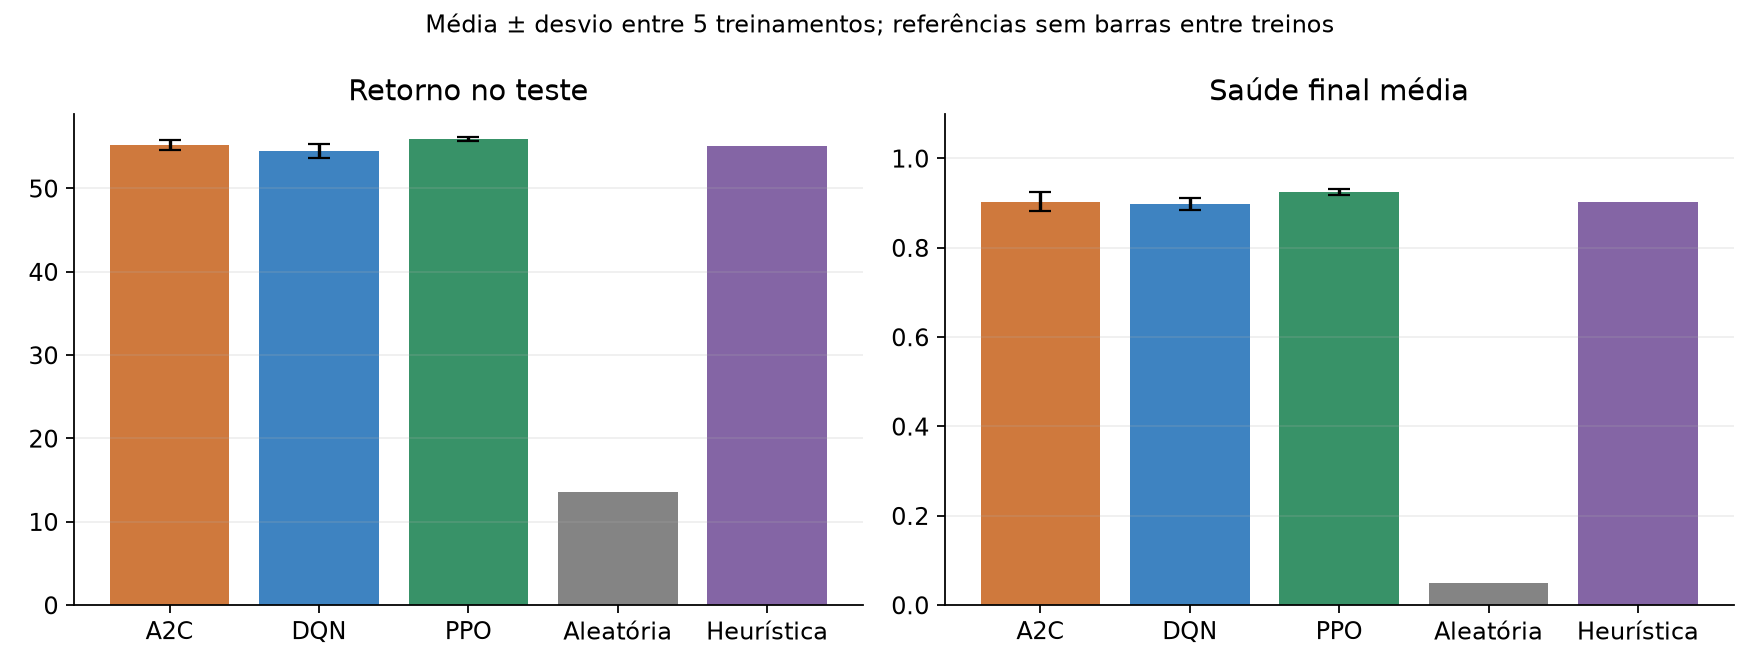

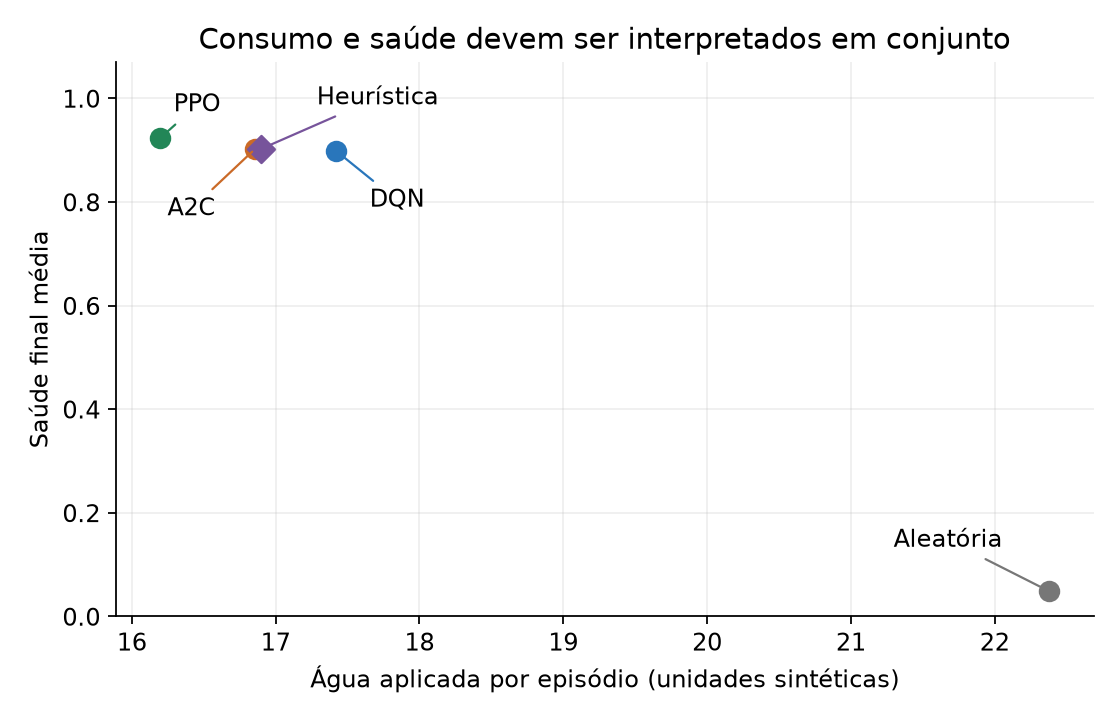

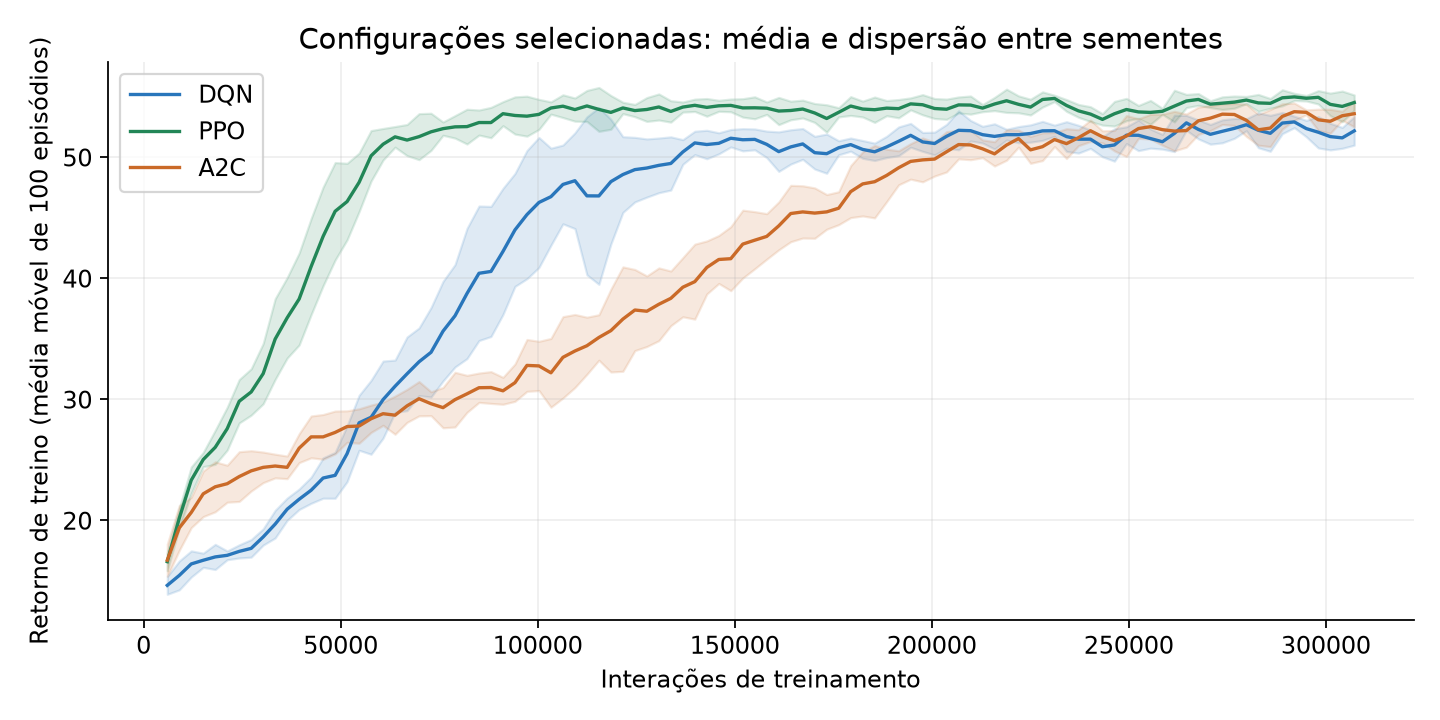

In [8]:
summary = pd.read_csv('results/final_summary.csv')
def mean_sd(row, metric, precision=2, percent=False):
    factor = 100 if percent else 1
    mean, sd = row[metric+'_mean'] * factor, row[metric+'_std'] * factor
    suffix = '%' if percent else ''
    if pd.isna(sd):
        return f'{mean:.{precision}f}{suffix}'
    return f'{mean:.{precision}f} ± {sd:.{precision}f}{suffix}'
display(pd.DataFrame([{
    'Algoritmo': row.algorithm, 'Configuração': row.config_id,
    'Retorno': mean_sd(row,'episode_return'),
    'Sobrevivência': mean_sd(row,'survival_fraction',1,True),
    'Saúde': mean_sd(row,'final_mean_health',3),
    'Água': mean_sd(row,'water_used'),
    'Sucesso': mean_sd(row,'success',1,True),
} for _,row in summary.iterrows()]))
display(summary[['algorithm','training_seeds','train_seconds_mean','train_seconds_std']].round(2))
display(Image(filename='reports/figures/comparacao.png'))
display(Image(filename='reports/figures/agua_saude.png'))
display(Image(filename='reports/figures/aprendizado.png'))

**PPO (`gamma_095`):** retorno 55.90 ± 0.26; sobrevivência 97.4%; saúde final 0.924; água 16.20; sucesso 94.2%. O desvio do retorno indica variação entre os treinamentos, além da diversidade dos episódios.

**A2C (`gamma_095`):** retorno 55.14 ± 0.61; sobrevivência 96.4%; saúde final 0.903; água 16.86; sucesso 92.8%. O desvio do retorno indica variação entre os treinamentos, além da diversidade dos episódios.

**DQN (`lr_3e-4`):** retorno 54.42 ± 0.84; sobrevivência 96.6%; saúde final 0.898; água 17.42; sucesso 92.2%. O desvio do retorno indica variação entre os treinamentos, além da diversidade dos episódios.

A referência aleatória obteve retorno 13.58, enquanto a heurística obteve 55.04. O melhor método de RL ficou +0.85 pontos em relação à heurística e +42.31 em relação à política aleatória. Essa comparação explicita se o aprendizado acrescenta benefício sobre uma regra baseada no conhecimento do simulador. Não foi aplicado teste de significância; a ordenação é descritiva.

O PPO combinou saúde final média 0.924 e consumo 16.20, contra 0.903 e 16.90 da heurística. A redução média de água foi de 4.2%, com maior saúde média neste conjunto. A política aleatória gastou 22.38 e terminou com saúde 0.049, mostrando que irrigar sem critério não basta. Essas diferenças são médias observadas, sem uma afirmação de significância estatística.

Nas curvas dos retreinamentos finais, o PPO alcançou retornos altos com menos interações, enquanto o A2C continuou melhorando ao longo de um período maior. A busca e o teste usam orçamentos e sementes diferentes; por isso, suas médias não devem ser tratadas como uma comparação controlada do efeito exclusivo do orçamento. O desempenho final também mostra por que avaliar somente um treino curto poderia subestimar o A2C.

As curvas exibem retornos coletados durante o treino, incluindo a exploração, e não os retornos determinísticos do teste. A suavização usa 100 episódios; as linhas são médias entre sementes em uma grade comum de interações e as faixas representam um desvio padrão. Dados brutos são mantidos nos arquivos Monitor. Consumir pouca água só é uma vantagem se a saúde também for preservada.

### 4.3 Execução ilustrativa

PPO, primeira semente de treino (101) e primeira semente de teste (2000) foram definidos para a demonstração. A trajetória não foi escolhida por apresentar o melhor resultado e não substitui as médias. A animação acompanha o repositório, e o MP4 para edição está em `apresentacao/execucao_ppo.mp4`, com cópia local em `videos/`.

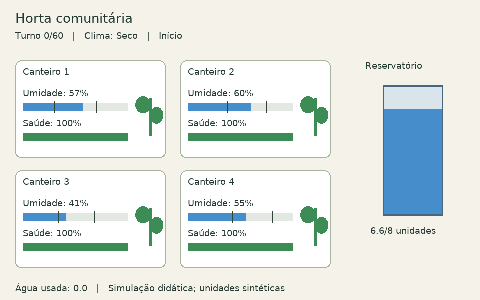

,turn,action,reward,water_used,survival_fraction,final_mean_health,weather,is_success,rain,water_step,new_deaths,invalid_action
0,1,5,1.00,0.0,1.0,1.0,0,False,0.00,0.0,0,0
1,2,2,0.90,1.0,1.0,1.0,0,False,0.00,1.0,0,0
2,3,3,0.90,2.0,1.0,1.0,0,False,0.00,1.0,0,0
3,4,5,1.00,2.0,1.0,1.0,0,False,0.00,0.0,0,0
4,5,5,1.00,2.0,1.0,1.0,0,False,0.00,0.0,0,0
5,6,1,0.90,3.0,1.0,1.0,1,False,0.00,1.0,0,0
6,7,5,1.00,3.0,1.0,1.0,1,False,0.00,0.0,0,0
7,8,2,0.90,4.0,1.0,1.0,1,False,0.04,1.0,0,0
8,9,5,1.00,4.0,1.0,1.0,0,False,0.00,0.0,0,0
9,10,4,0.95,4.0,1.0,1.0,0,False,0.00,0.0,0,0


In [9]:
display(Image(filename='reports/figures/execucao_ppo.gif'))
display(pd.read_csv('results/demo_trajectory.csv').head(10))

## 5. Conclusões

O ambiente implementado permite relacionar o MDP a uma tarefa de gestão de recursos e comparar três métodos profundos. No protocolo executado, PPO apresentou o maior retorno médio entre os algoritmos de RL. O sucesso médio foi de 94.2%; esse indicador deve ser lido junto à dispersão do retorno, à saúde e ao consumo. A heurística atingiu retorno 55.04, oferecendo uma referência de solução por conhecimento das regras. Os resultados descrevem este cenário, sem estabelecer uma classificação geral de algoritmos.

### Limitações, dificuldades e trabalhos futuros

O clima e as equações de saúde foram escolhidos para produzir um problema didático, sem calibração empírica. A política observa o estado completo e a reposição de água externa é ilimitada, embora exija uma ação. A busca tem somente quatro configurações por algoritmo e não explora conjuntamente todos os parâmetros; a arquitetura foi fixada. Cinco sementes finais ajudam a revelar variação, mas não eliminam incerteza. O ajuste dos pesos de recompensa e da arquitetura não foi incluído nos experimentos.

O registro de parâmetros do A2C e os acentos da renderização exigiram correção no piloto. O agendador também precisou configurar threads do PyTorch somente na inicialização de cada processo, preservando os resultados concluídos ao retomar. Essas correções operacionais não alteraram o MDP ou os hiperparâmetros. A separação entre sementes de treino, validação e teste, a preservação de tentativas e a distinção entre episódios e treinamentos foram cuidados essenciais na organização do trabalho. A execução de treinos em paralelo também limita comparações estritas de tempo de CPU. O registro operacional está em `results/operational_notes.md`.

Como continuidade, propomos avaliar sensores ruidosos, reservatório captando chuva, escassez real da fonte de reposição, outras espécies, maior busca de hiperparâmetros e testes estatísticos com mais sementes. Esses itens são extensões, não funcionalidades já implementadas.

## 6. Apresentação e entrega

A apresentação deve durar no máximo três minutos, com todos os integrantes falando, e estar no YouTube. O roteiro em `apresentacao/roteiro.md` prioriza MDP e resultados. A animação gerada é material de apoio e não substitui a apresentação dos integrantes. O link da apresentação deve constar no relatório. A divulgação em redes sociais é opcional, com link no relatório se realizada.

## Referências

- Materiais da disciplina: notebooks dos módulos 1 a 4. O módulo 3 exemplifica PPO; os módulos 1 e 4 tratam de ambientes próprios.
- [Gymnasium: criação de ambiente](https://gymnasium.farama.org/tutorials/gymnasium_basics/environment_creation/).
- [Stable-Baselines3: repositório](https://github.com/DLR-RM/stable-baselines3) e [orientações de experimentação](https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html).
- [DQN: documentação](https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html); Mnih et al., [Playing Atari with Deep Reinforcement Learning](https://arxiv.org/abs/1312.5602), 2013.
- [PPO: documentação](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html); Schulman et al., [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347), 2017.
- [A2C: documentação](https://stable-baselines3.readthedocs.io/en/master/modules/a2c.html). A família de métodos por vantagem com ator e crítico é apresentada por Mnih et al. em [Asynchronous Methods for Deep Reinforcement Learning](https://arxiv.org/abs/1602.01783), 2016; o A2C usado aqui é a variante síncrona da SB3, não o A3C assíncrono do artigo.
